In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('concrete_data.csv')

In [4]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
161,337.9,189.0,0.0,174.9,9.5,944.7,755.8,56,59.89
478,446.0,24.0,79.0,162.0,11.6,967.0,712.0,7,52.01
671,236.0,157.0,0.0,192.0,0.0,972.6,749.1,7,20.42
868,276.0,116.0,90.0,180.0,9.0,870.0,768.0,28,44.28
15,380.0,0.0,0.0,228.0,0.0,932.0,670.0,90,52.91


In [5]:
df.shape, df.isnull().sum()

((1030, 9),
 Cement                0
 Blast Furnace Slag    0
 Fly Ash               0
 Water                 0
 Superplasticizer      0
 Coarse Aggregate      0
 Fine Aggregate        0
 Age                   0
 Strength              0
 dtype: int64)

In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
x = df.drop(columns=['Strength'])
y = df['Strength']

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.6275531792314848

In [20]:
np.mean(cross_val_score(lr,x,y,scoring='r2'))

0.4609940491662864

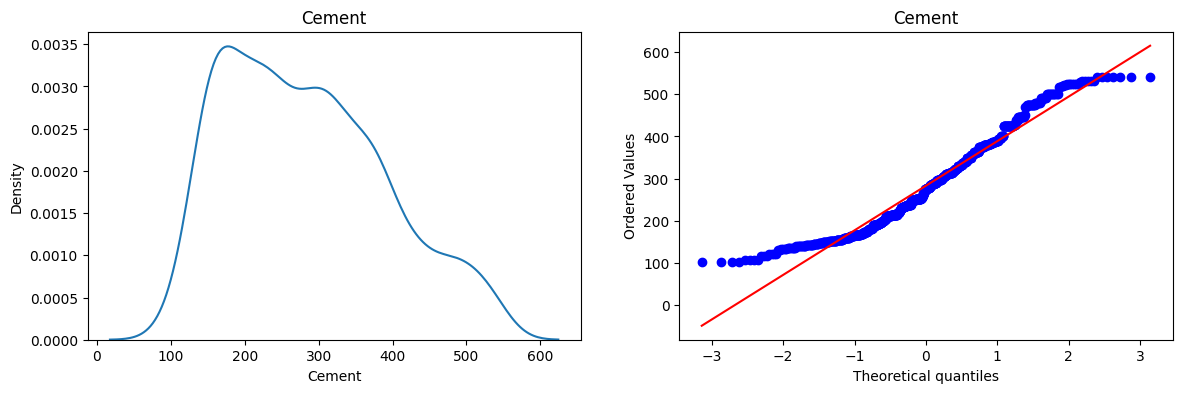

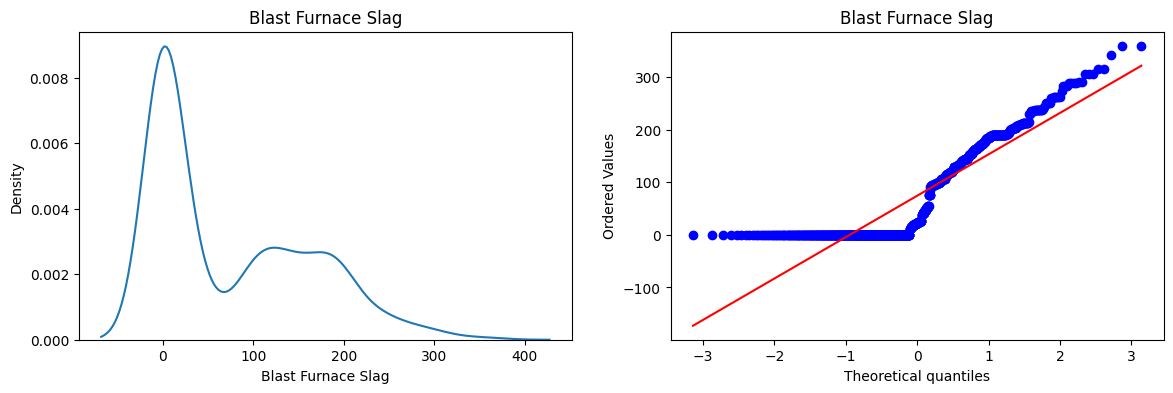

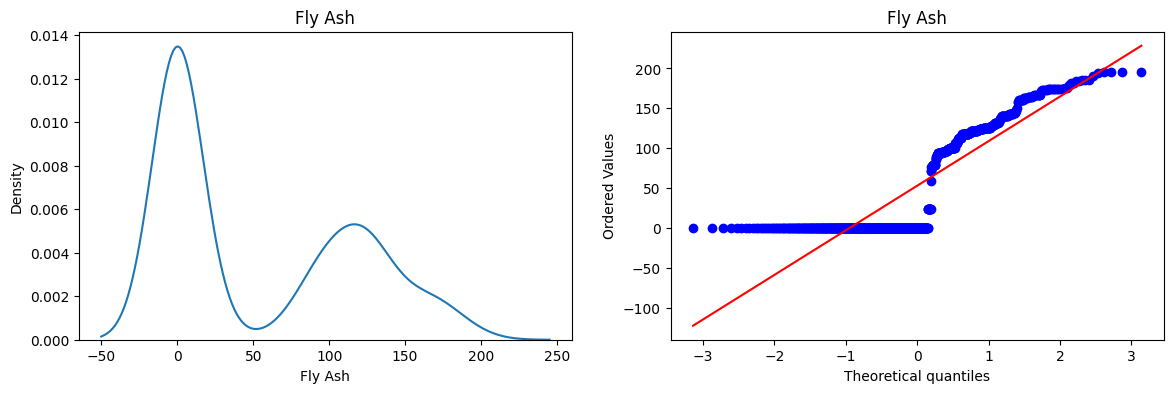

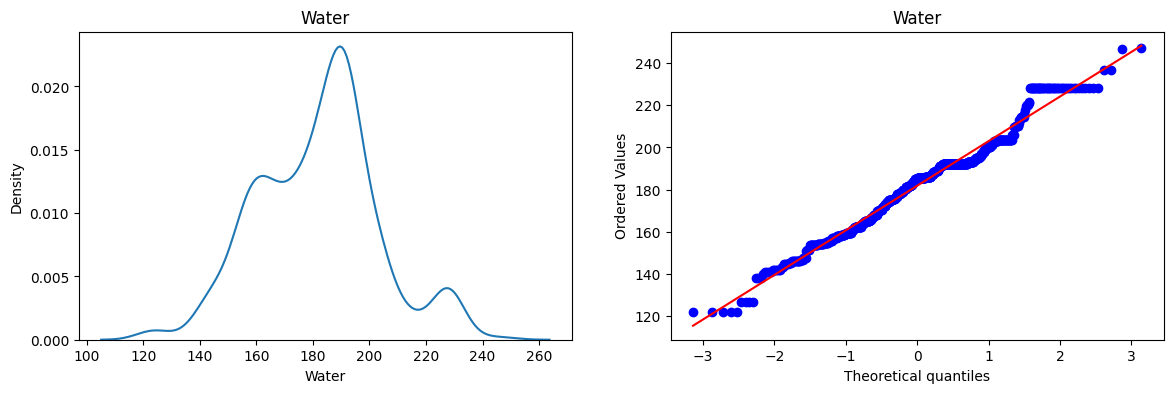

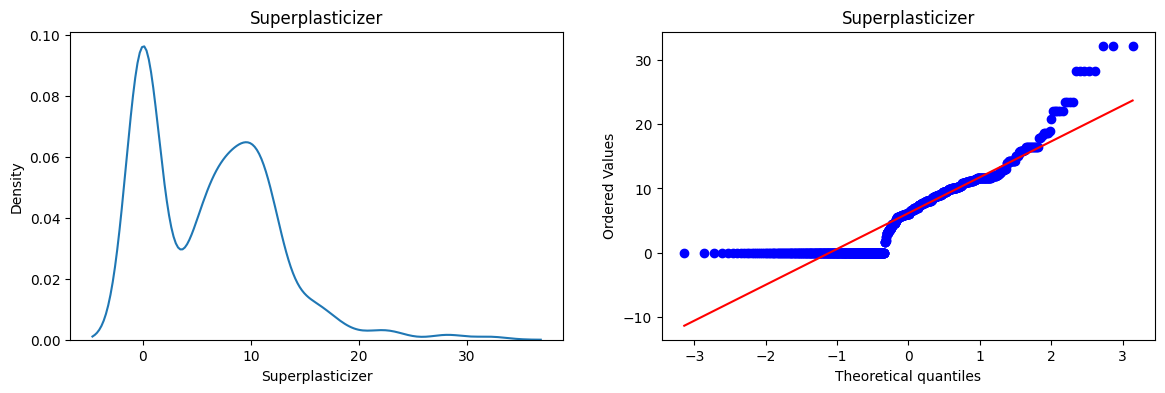

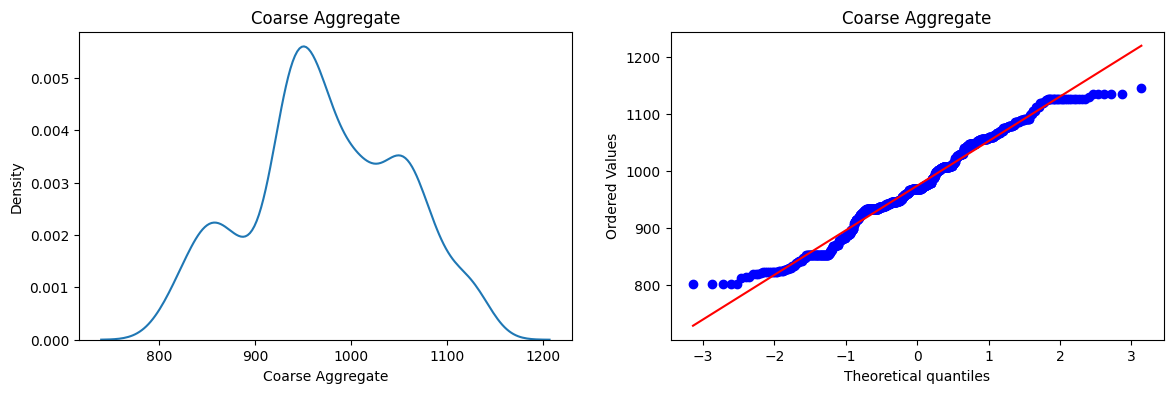

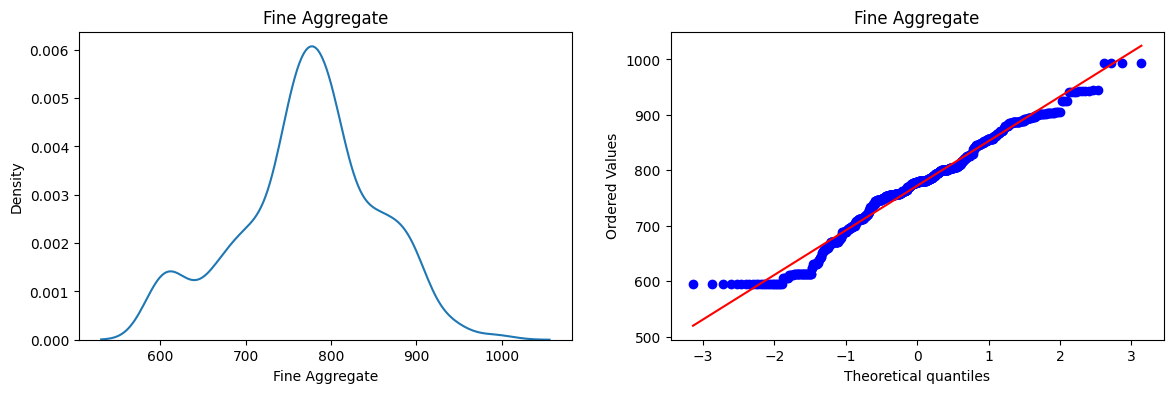

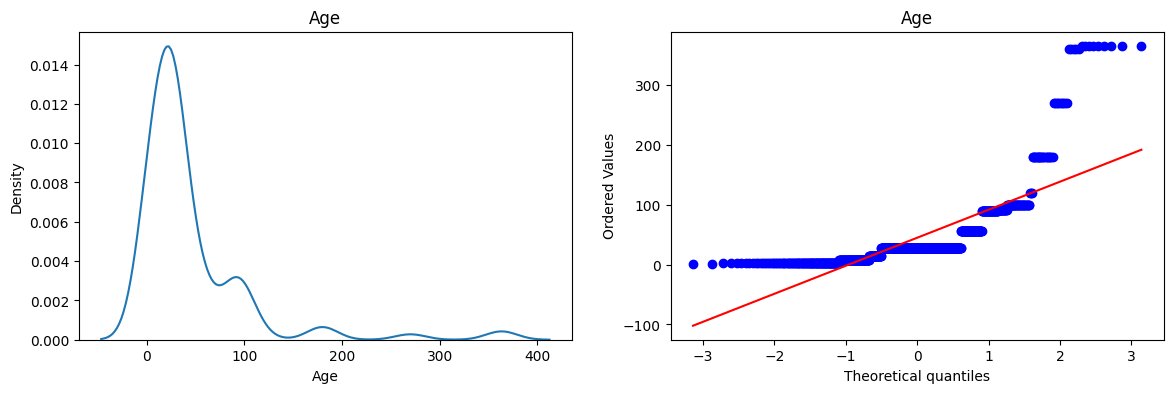

In [24]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121) #row,column,plotno
    sns.kdeplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col],dist="norm",plot=plt)
    plt.title(col)
    plt.show()

In [25]:
pt = PowerTransformer(method='box-cox')

x_train_transformed = pt.fit_transform(x_train+0.000001)
x_test_transformed = pt.transform(x_test+0.000001)

pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [27]:
lr = LinearRegression()
lr.fit(x_train_transformed,y_train)

y_pred = lr.predict(x_test_transformed)
r2_score(y_test,y_pred)

0.8047825011695536

In [28]:
x_transformed = pt.fit_transform(x+0.000001)
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

0.6662950324463965

In [29]:
x_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)

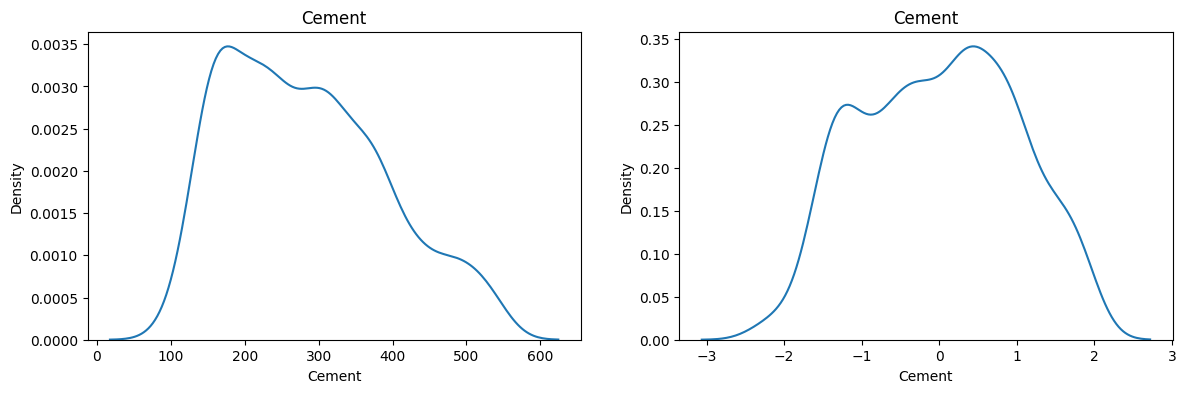

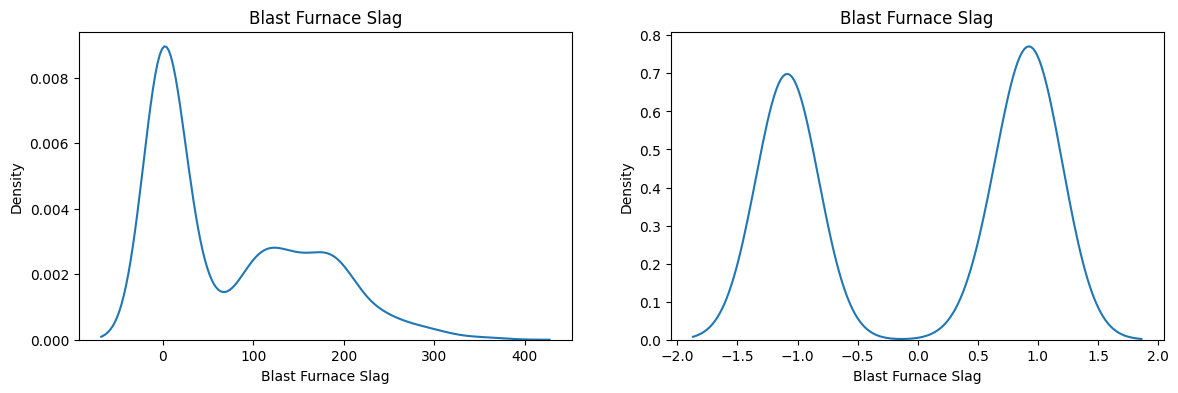

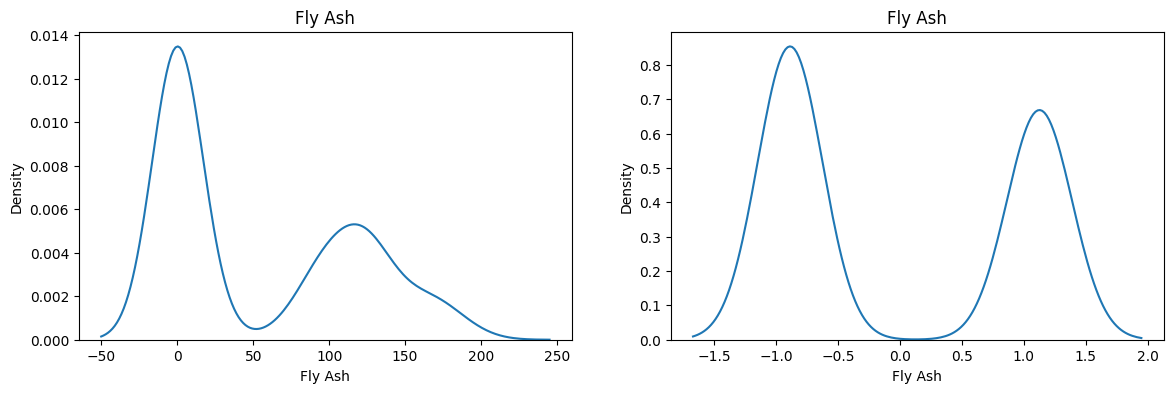

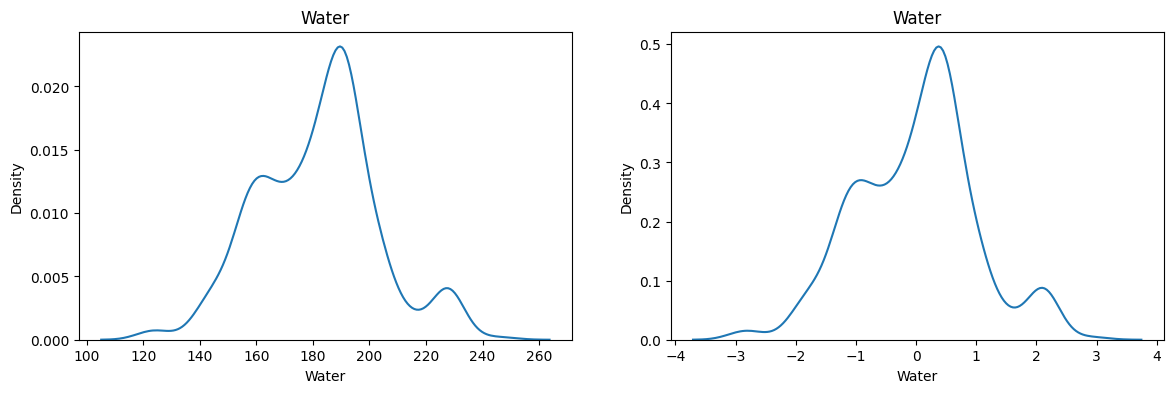

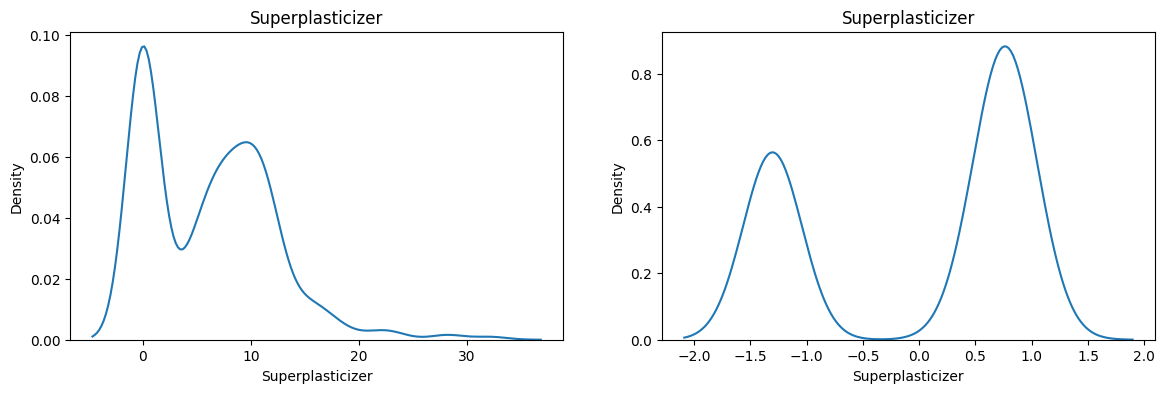

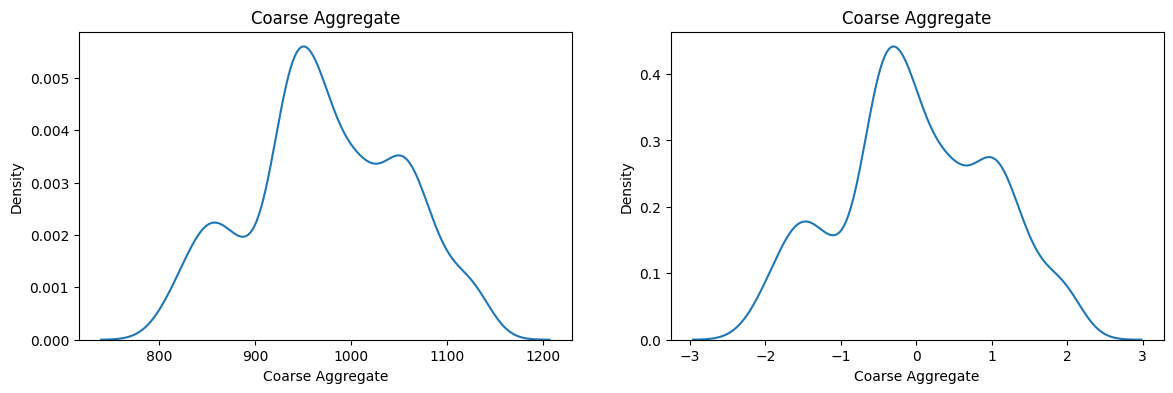

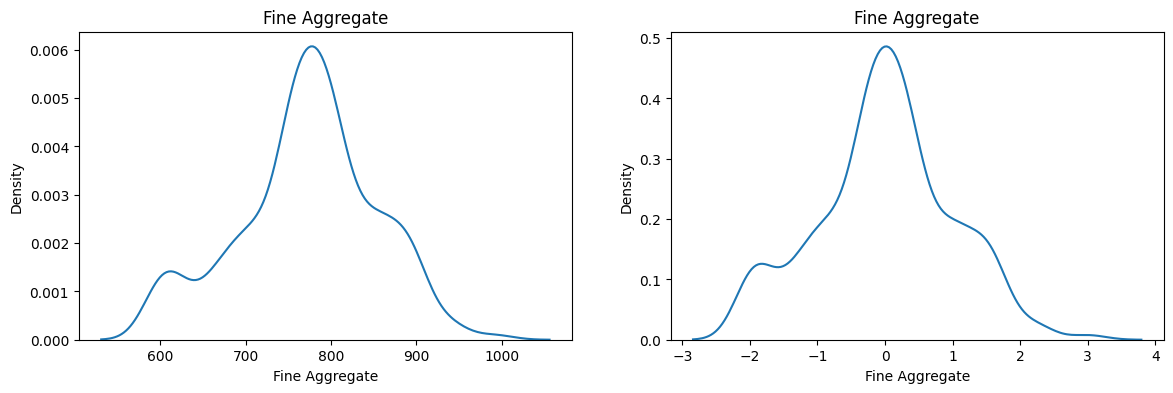

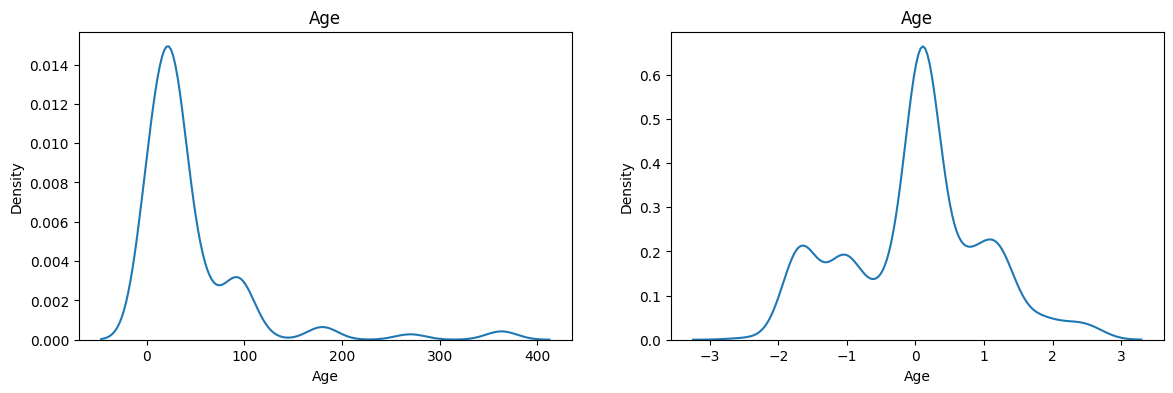

In [30]:
for col in x_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.kdeplot(x_train_transformed[col])
    plt.title(col)

    plt.show()

In [34]:
pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed2,y_train)

y_pred2 = lr.predict(x_test_transformed2)

r2_score(y_test,y_pred2)

0.8161906513354853

In [36]:
x_trans = pt1.fit_transform(x)
np.mean(cross_val_score(lr,x_trans,y,scoring='r2'))

0.6834625141500864